# 01 — Data Exploration
Inspect the Hotel Reviews dataset: shape, missing values, rating distribution, top hotels, and date coverage.

In [2]:
import sys, pathlib
ROOT = str(pathlib.Path().resolve().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data_processing.data_loader import load_hotel_reviews
from src.data_processing.data_cleaner import clean_reviews

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. Load raw data

In [3]:
raw = load_hotel_reviews()
print(f'Shape: {raw.shape}')
raw.head(3)

18:54:39 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
18:54:42 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")


Shape: (515738, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968


## 2. Column types & missing values

In [3]:
info = pd.DataFrame({
    'dtype':   raw.dtypes,
    'missing': raw.isna().sum(),
    'missing%': (raw.isna().mean() * 100).round(2)
})
info

,dtype,missing,missing%
Hotel_Address,object,0,0.00
Additional_Number_of_Scoring,int64,0,0.00
Review_Date,datetime64[ns],0,0.00
Average_Score,float64,0,0.00
Hotel_Name,object,0,0.00
Reviewer_Nationality,object,0,0.00
Negative_Review,object,0,0.00
Review_Total_Negative_Word_Counts,int64,0,0.00
Total_Number_of_Reviews,int64,0,0.00
Positive_Review,object,0,0.00


## 3. Clean and derive features

In [4]:
df = clean_reviews(raw)
print(f'Cleaned shape: {df.shape}')

preview_candidates = ['hotel_name', 'Hotel_Name', 'date', 'rating', 'review_length']
preview_cols = [c for c in preview_candidates if c in df.columns]
df[preview_cols].head(5)

18:54:50 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 515738
18:54:51 [INFO] src.data_processing.data_cleaner: Dropped 526 duplicate rows.
18:54:56 [INFO] src.data_processing.data_cleaner: Dropped 421 rows with empty review text.
18:54:58 [INFO] src.data_processing.data_cleaner: Cleaned dataset: 514791 rows remaining.


Cleaned shape: (514791, 22)


,Hotel_Name,date,rating,review_length
0,Hotel Arena,2017-08-03,1.45,1910
1,Hotel Arena,2017-08-03,3.75,609
2,Hotel Arena,2017-07-31,3.55,298
3,Hotel Arena,2017-07-31,1.90,1218
4,Hotel Arena,2017-07-24,3.35,771


## 4. Rating distribution

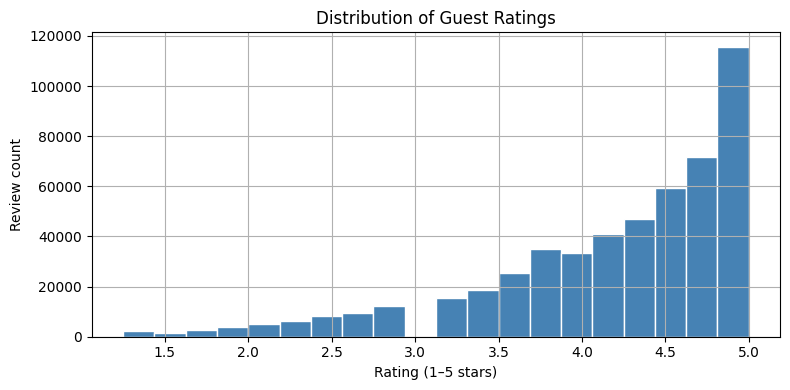

count    514791.000
mean          4.198
std           0.818
min           1.250
25%           3.750
50%           4.400
75%           4.800
max           5.000
Name: rating, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df['rating'].hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Rating (1–5 stars)')
ax.set_ylabel('Review count')
ax.set_title('Distribution of Guest Ratings')
plt.tight_layout()
plt.show()
print(df['rating'].describe().round(3))

## 5. Top 20 hotels by review count

In [6]:
top_hotels = (
    df.groupby('Hotel_Name')
      .agg(reviews=('rating', 'count'), avg_rating=('rating', 'mean'))
      .sort_values('reviews', ascending=False)
      .head(20)
)
top_hotels['avg_rating'] = top_hotels['avg_rating'].round(2)
top_hotels

,reviews,avg_rating
Hotel_Name,,
Britannia International Hotel Canary Wharf,4782,3.41
Strand Palace Hotel,4250,4.06
Park Plaza Westminster Bridge London,4169,4.33
Copthorne Tara Hotel London Kensington,3572,4.05
DoubleTree by Hilton Hotel London Tower of London,3208,4.33
Grand Royale London Hyde Park,2957,3.81
Holiday Inn London Kensington,2767,3.86
Hilton London Metropole,2624,3.66
Millennium Gloucester Hotel London,2563,3.84


## 6. Review date coverage

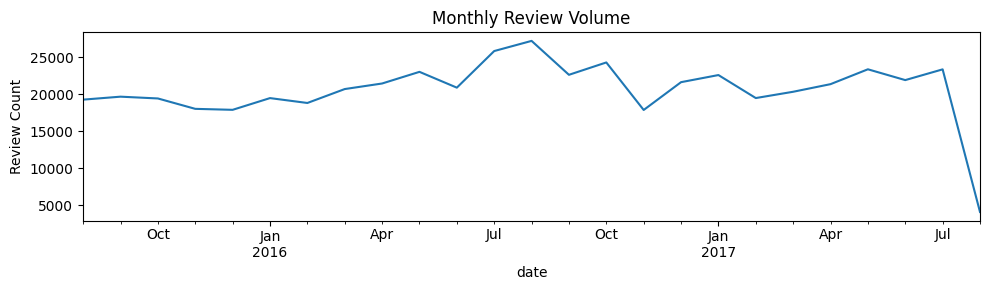

In [7]:
monthly = df.set_index('date').resample('ME')['rating'].count()
monthly.plot(figsize=(10, 3), title='Monthly Review Volume', ylabel='Review Count')
plt.tight_layout()
plt.show()

## 7. Review length distribution

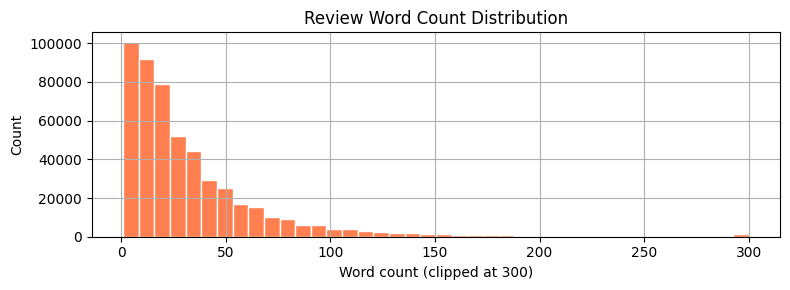

count    514791.0
mean         33.7
std          38.5
min           1.0
25%          10.0
50%          22.0
75%          43.0
max         733.0
Name: word_count, dtype: float64


In [8]:
df['word_count'].clip(upper=300).hist(bins=40, figsize=(8, 3), color='coral', edgecolor='white')
plt.xlabel('Word count (clipped at 300)')
plt.ylabel('Count')
plt.title('Review Word Count Distribution')
plt.tight_layout()
plt.show()
print(df['word_count'].describe().round(1))